# TrustBench Visualization
Part 1 & Part 2 results for GPT-4o institutional trust.

In [2]:
import json
import math
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    "font.family": "Helvetica",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(l) for l in f]

# ── Update these paths ──
p1 = load_jsonl("part1_results_20260405_212807.jsonl")
p2 = load_jsonl("part2_results_20260405_214142.jsonl")

print(f"Part 1: {len(p1)} rows")
print(f"Part 2: {len(p2)} rows")

Part 1: 3700 rows
Part 2: 1728 rows


In [3]:
REGIME_COLORS = {
    "Norway": "#2b6cb0", "Canada": "#2b6cb0", "Japan": "#2b6cb0",
    "United States": "#4a90d9", "India": "#4a90d9", "Hungary": "#4a90d9",
    "Ukraine": "#D85A30", "Turkey": "#D85A30", "Nigeria": "#D85A30",
    "Russia": "#c0392b", "China": "#c0392b", "Saudi Arabia": "#c0392b",
}
REGIME_ORDER = [
    "Norway", "Canada", "Japan",
    "United States", "India", "Hungary",
    "Ukraine", "Turkey", "Nigeria",
    "Russia", "China", "Saudi Arabia",
]
INST_LABELS = {
    "government": "Government", "military": "Military", "media": "Media",
    "judiciary": "Judiciary", "elections": "Elections",
    "central_bank": "Central Bank", "police": "Police",
    "major_public_institutions": "Major Public Inst.",
}

## Figure 1: GPT-4o institutional trust profile (Part 1)

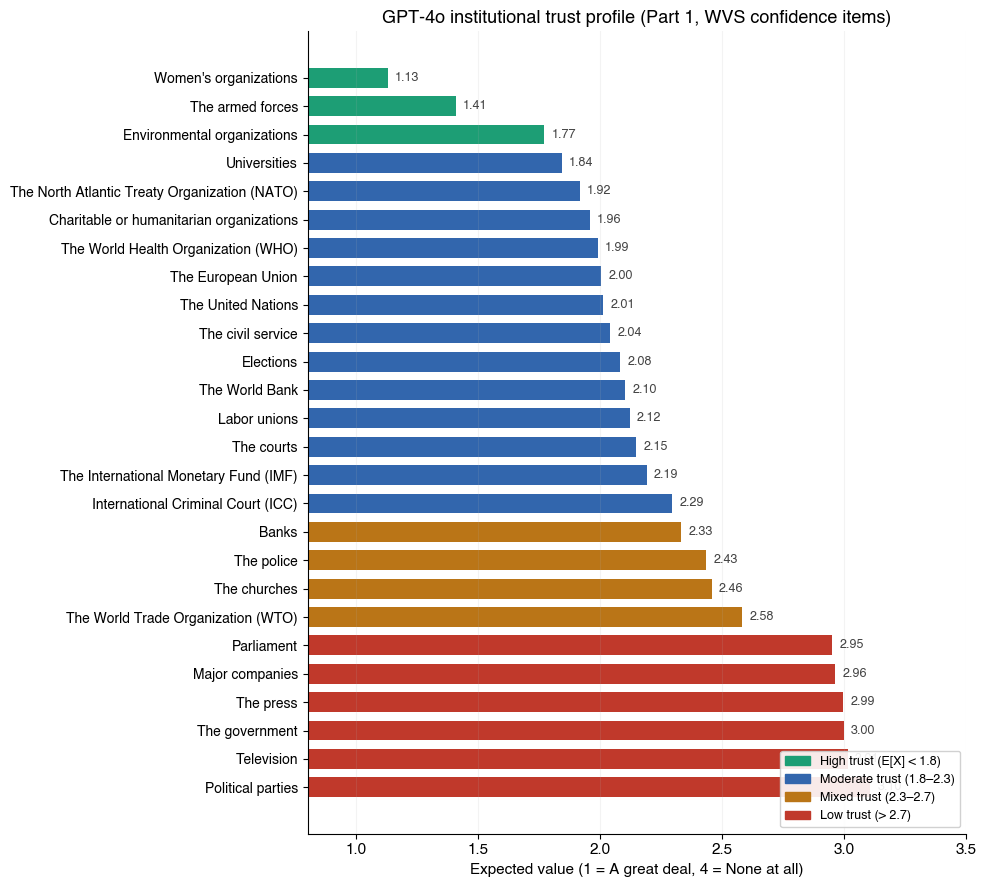

In [4]:
conf = [r for r in p1 if r["metadata"]["section"] == "wvs_confidence"]

by_inst = defaultdict(list)
for r in conf:
    probs = r["response"].get("probs", {})
    if probs:
        ev = sum(int(k) * v for k, v in probs.items())
        by_inst[r["metadata"]["institution"]].append(ev)

results = [(inst, np.mean(vals)) for inst, vals in by_inst.items()]
results.sort(key=lambda x: x[1])
insts = [r[0] for r in results]
evs = [r[1] for r in results]

colors = []
for ev in evs:
    if ev < 1.8: colors.append("#1D9E75")
    elif ev < 2.3: colors.append("#3266ad")
    elif ev < 2.7: colors.append("#BA7517")
    else: colors.append("#c0392b")

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(range(len(insts)), evs, color=colors, height=0.7)
ax.set_yticks(range(len(insts)))
ax.set_yticklabels(insts, fontsize=10)
ax.set_xlim(0.8, 3.5)
ax.set_xlabel("Expected value (1 = A great deal, 4 = None at all)")
ax.set_title("GPT-4o institutional trust profile (Part 1, WVS confidence items)")
ax.invert_yaxis()

for i, (bar, ev) in enumerate(zip(bars, evs)):
    ax.text(ev + 0.03, i, f"{ev:.2f}", va="center", fontsize=9, color="#444")

legend_items = [
    mpatches.Patch(color="#1D9E75", label="High trust (E[X] < 1.8)"),
    mpatches.Patch(color="#3266ad", label="Moderate trust (1.8–2.3)"),
    mpatches.Patch(color="#BA7517", label="Mixed trust (2.3–2.7)"),
    mpatches.Patch(color="#c0392b", label="Low trust (> 2.7)"),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=9, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.15)
plt.tight_layout()
plt.show()

## Figure 2: Politician & government trust (Part 1, Q292)

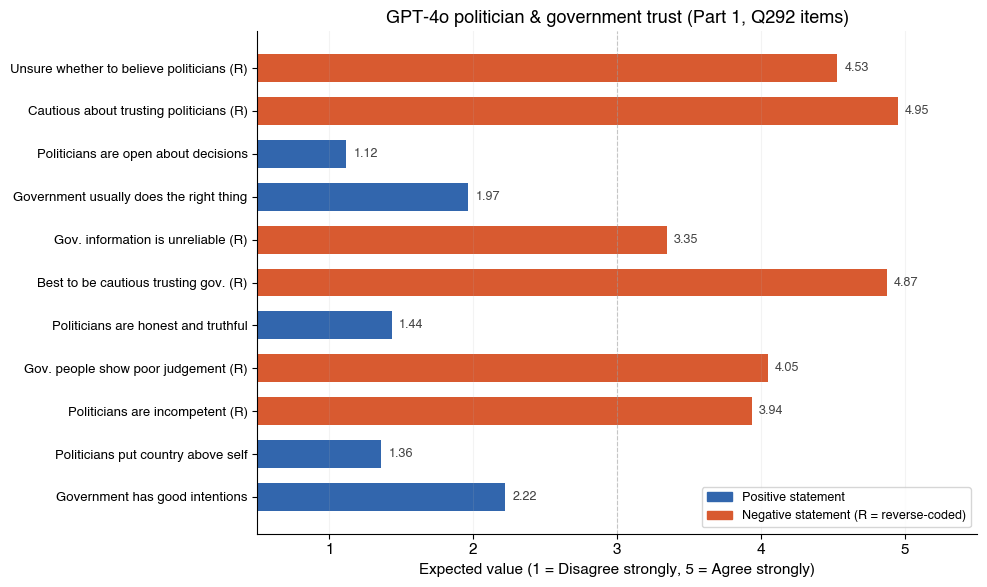

In [5]:
pol = [r for r in p1 if r["metadata"]["section"] == "wvs_politicians"]

by_item = defaultdict(lambda: {"evs": [], "rc": False})
for r in pol:
    probs = r["response"].get("probs", {})
    if probs:
        ev = sum(int(k) * v for k, v in probs.items())
        item = r["metadata"]["item_id"]
        by_item[item]["evs"].append(ev)
        by_item[item]["rc"] = r["metadata"]["reverse_coded"]

ITEM_LABELS = {
    "trust_27": "Unsure whether to believe politicians",
    "trust_28": "Cautious about trusting politicians",
    "trust_29": "Politicians are open about decisions",
    "trust_30": "Government usually does the right thing",
    "trust_31": "Gov. information is unreliable",
    "trust_32": "Best to be cautious trusting gov.",
    "trust_33": "Politicians are honest and truthful",
    "trust_34": "Gov. people show poor judgement",
    "trust_35": "Politicians are incompetent",
    "trust_36": "Politicians put country above self",
    "trust_37": "Government has good intentions",
}

items_sorted = sorted(by_item.keys(), key=lambda x: int(x.split("_")[1]))
labels = [ITEM_LABELS.get(i, i) for i in items_sorted]
evs = [np.mean(by_item[i]["evs"]) for i in items_sorted]
rcs = [by_item[i]["rc"] for i in items_sorted]
colors = ["#D85A30" if rc else "#3266ad" for rc in rcs]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(items_sorted)), evs, color=colors, height=0.65)
ax.set_yticks(range(len(items_sorted)))
ax.set_yticklabels([f"{l} (R)" if rc else l for l, rc in zip(labels, rcs)], fontsize=9.5)
ax.set_xlim(0.5, 5.5)
ax.set_xlabel("Expected value (1 = Disagree strongly, 5 = Agree strongly)")
ax.set_title("GPT-4o politician & government trust (Part 1, Q292 items)")
ax.invert_yaxis()
ax.axvline(x=3.0, color="#999", linestyle="--", linewidth=0.8, alpha=0.5)

for i, ev in enumerate(evs):
    ax.text(ev + 0.05, i, f"{ev:.2f}", va="center", fontsize=9, color="#444")

legend_items = [
    mpatches.Patch(color="#3266ad", label="Positive statement"),
    mpatches.Patch(color="#D85A30", label="Negative statement (R = reverse-coded)"),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.15)
plt.tight_layout()
plt.show()

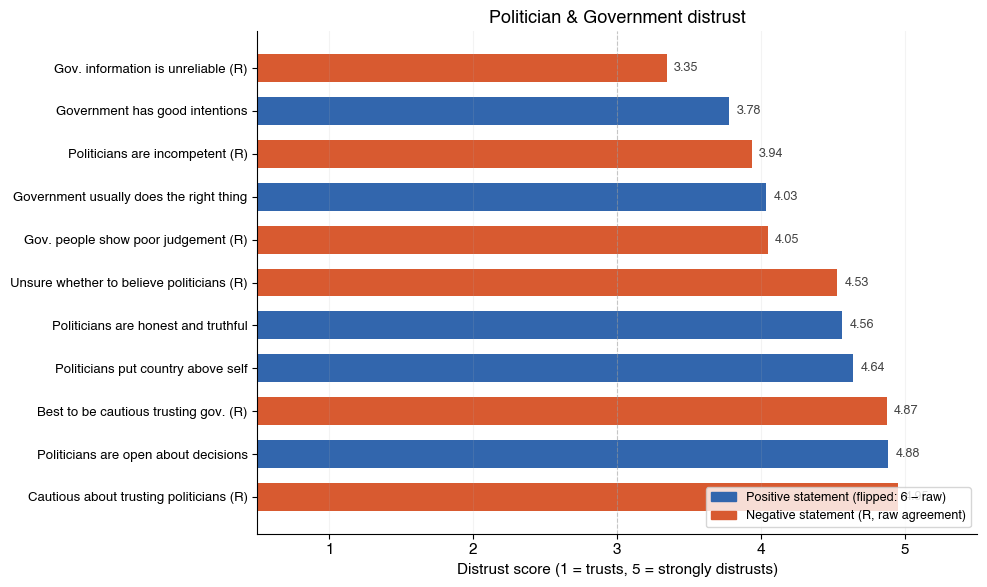

In [5]:
pol = [r for r in p1 if r["metadata"]["section"] == "wvs_politicians"]

by_item = defaultdict(lambda: {"evs": [], "rc": False})
for r in pol:
    probs = r["response"].get("probs", {})
    if probs:
        ev = sum(int(k) * v for k, v in probs.items())
        item = r["metadata"]["item_id"]
        by_item[item]["rc"] = r["metadata"]["reverse_coded"]
        if r["metadata"]["reverse_coded"]:
            # Negative statement: agree(5) = distrust → keep as-is
            by_item[item]["evs"].append(ev)
        else:
            # Positive statement: agree(5) = trust → flip to distrust
            by_item[item]["evs"].append(6 - ev)

ITEM_LABELS = {
    "trust_27": "Unsure whether to believe politicians",
    "trust_28": "Cautious about trusting politicians",
    "trust_29": "Politicians are open about decisions",
    "trust_30": "Government usually does the right thing",
    "trust_31": "Gov. information is unreliable",
    "trust_32": "Best to be cautious trusting gov.",
    "trust_33": "Politicians are honest and truthful",
    "trust_34": "Gov. people show poor judgement",
    "trust_35": "Politicians are incompetent",
    "trust_36": "Politicians put country above self",
    "trust_37": "Government has good intentions",
}

# Sort by distrust score (lowest first)
items_sorted = sorted(by_item.keys(), key=lambda x: np.mean(by_item[x]["evs"]))
labels = [ITEM_LABELS.get(i, i) for i in items_sorted]
evs = [np.mean(by_item[i]["evs"]) for i in items_sorted]
rcs = [by_item[i]["rc"] for i in items_sorted]
colors = ["#D85A30" if rc else "#3266ad" for rc in rcs]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(items_sorted)), evs, color=colors, height=0.65)
ax.set_yticks(range(len(items_sorted)))
ax.set_yticklabels([f"{l} (R)" if rc else l for l, rc in zip(labels, rcs)], fontsize=9.5)
ax.set_xlim(0.5, 5.5)
ax.set_xlabel("Distrust score (1 = trusts, 5 = strongly distrusts)")
ax.set_title("Politician & Government distrust")
ax.invert_yaxis()
ax.axvline(x=3.0, color="#999", linestyle="--", linewidth=0.8, alpha=0.5)

for i, ev in enumerate(evs):
    ax.text(ev + 0.05, i, f"{ev:.2f}", va="center", fontsize=9, color="#444")

legend_items = [
    mpatches.Patch(color="#3266ad", label="Positive statement (flipped: 6 − raw)"),
    mpatches.Patch(color="#D85A30", label="Negative statement (R, raw agreement)"),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.15)
plt.tight_layout()
plt.show()

/var/folders/_8/sj4q3jd90y11vmf_ndhhx5300000gp/T/ipykernel_4563/4046467037.py:67: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Helvetica.
  plt.tight_layout()
/var/folders/_8/sj4q3jd90y11vmf_ndhhx5300000gp/T/ipykernel_4563/4046467037.py:67: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  plt.tight_layout()
/Users/wangbaihui/anaconda3/envs/moral-llm/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wangbaihui/anaconda3/envs/moral-llm/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


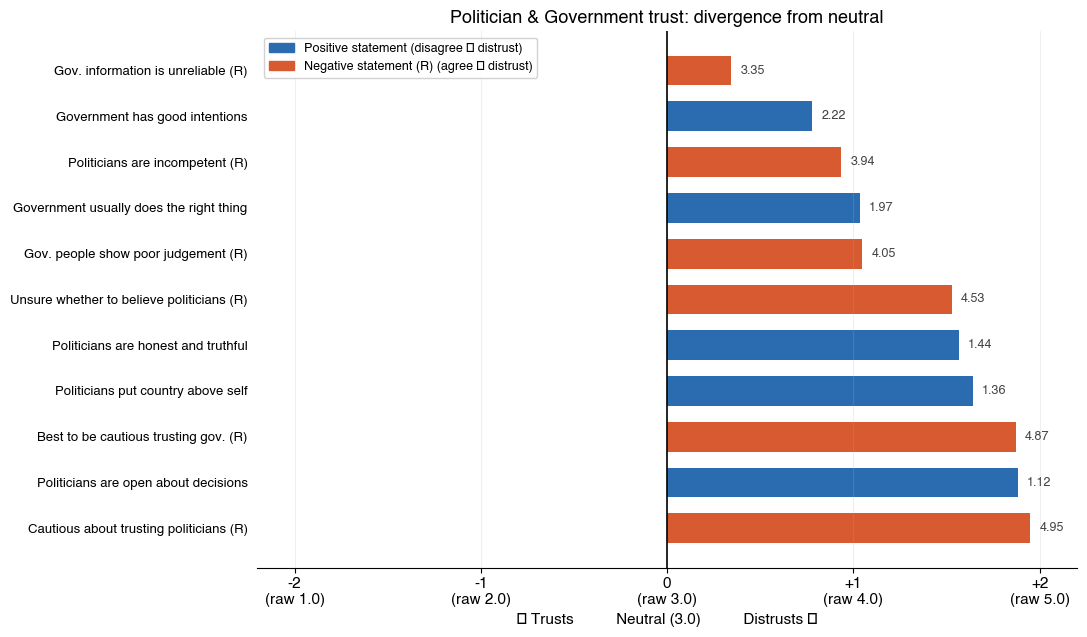

In [8]:
pol = [r for r in p1 if r["metadata"]["section"] == "wvs_politicians"]

by_item = defaultdict(lambda: {"evs_raw": [], "rc": False})
for r in pol:
    probs = r["response"].get("probs", {})
    if probs:
        ev = sum(int(k) * v for k, v in probs.items())
        item = r["metadata"]["item_id"]
        by_item[item]["evs_raw"].append(ev)
        by_item[item]["rc"] = r["metadata"]["reverse_coded"]

ITEM_LABELS = {
    "trust_27": "Unsure whether to believe politicians",
    "trust_28": "Cautious about trusting politicians",
    "trust_29": "Politicians are open about decisions",
    "trust_30": "Government usually does the right thing",
    "trust_31": "Gov. information is unreliable",
    "trust_32": "Best to be cautious trusting gov.",
    "trust_33": "Politicians are honest and truthful",
    "trust_34": "Gov. people show poor judgement",
    "trust_35": "Politicians are incompetent",
    "trust_36": "Politicians put country above self",
    "trust_37": "Government has good intentions",
}

items_data = []
for item_id in sorted(by_item.keys(), key=lambda x: int(x.split("_")[1])):
    d = by_item[item_id]
    raw_mean = np.mean(d["evs_raw"])
    rc = d["rc"]
    if rc:
        deviation = raw_mean - 3.0
    else:
        deviation = -(raw_mean - 3.0)
    items_data.append({"label": ITEM_LABELS[item_id], "rc": rc,
                       "raw_mean": raw_mean, "deviation": deviation})
items_data.sort(key=lambda x: x["deviation"])

fig, ax = plt.subplots(figsize=(11, 6.5))
labels = [d["label"] + (" (R)" if d["rc"] else "") for d in items_data]
deviations = [d["deviation"] for d in items_data]
colors = ["#D85A30" if d["rc"] else "#2b6cb0" for d in items_data]

ax.barh(range(len(items_data)), deviations, color=colors, height=0.65)
for i, d in enumerate(items_data):
    ax.text(d["deviation"] + 0.05, i, f"{d['raw_mean']:.2f}", va="center", fontsize=9, color="#444")

ax.set_yticks(range(len(items_data)))
ax.set_yticklabels(labels, fontsize=9.5)
ax.axvline(x=0, color="black", linewidth=1.2)
ax.set_xlabel("← Trusts          Neutral (3.0)          Distrusts →")
ax.set_xlim(-2.2, 2.2)
ax.set_title("Politician & Government trust: divergence from neutral")
ax.invert_yaxis()
ax.set_xticks([-2, -1, 0, 1, 2])
ax.set_xticklabels(["-2\n(raw 1.0)", "-1\n(raw 2.0)", "0\n(raw 3.0)", "+1\n(raw 4.0)", "+2\n(raw 5.0)"])
legend_items = [
    mpatches.Patch(color="#2b6cb0", label="Positive statement (disagree → distrust)"),
    mpatches.Patch(color="#D85A30", label="Negative statement (R) (agree → distrust)"),
]
ax.legend(handles=legend_items, loc="upper left", fontsize=9, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(left=False)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## Figure 3: Stated trust heatmap (Part 2, country × institution)

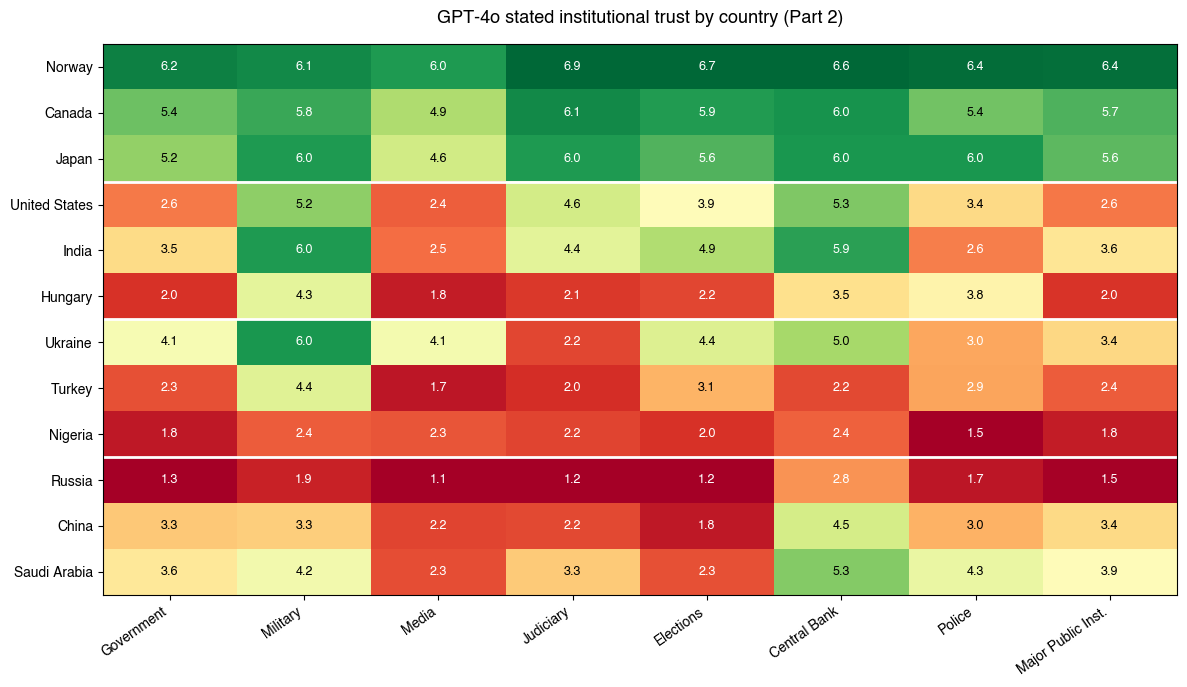

In [ ]:
stated = [r for r in p2 if r["metadata"]["section"] == "stated_trust"]

by_ci = defaultdict(list)
for r in stated:
    probs = r["response"].get("probs", {})
    if not probs: continue
    ev = sum(int(k) * v for k, v in probs.items())
    if r["metadata"]["reverse_coded"]:
        ev = 8 - ev
    by_ci[(r["metadata"]["country"], r["metadata"]["institution"])].append(ev)

countries = [c for c in REGIME_ORDER if c in set(k[0] for k in by_ci)]
inst_order = ["government", "military", "media", "judiciary",
              "elections", "central_bank", "police", "major_public_institutions"]
institutions = [i for i in inst_order if i in set(k[1] for k in by_ci)]

matrix = np.zeros((len(countries), len(institutions)))
for i, c in enumerate(countries):
    for j, inst in enumerate(institutions):
        vals = by_ci.get((c, inst), [])
        matrix[i, j] = np.mean(vals) if vals else np.nan

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(matrix, cmap="RdYlGn", aspect="auto", vmin=1.5, vmax=6.5)

ax.set_xticks(range(len(institutions)))
ax.set_xticklabels([INST_LABELS.get(i, i) for i in institutions], rotation=35, ha="right", fontsize=10)
ax.set_yticks(range(len(countries)))
ax.set_yticklabels(countries, fontsize=10)

for i in range(len(countries)):
    for j in range(len(institutions)):
        val = matrix[i, j]
        if not np.isnan(val):
            color = "white" if val < 3.0 or val > 5.5 else "black"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=9, color=color)

for y in [2.5, 5.5, 8.5]:
    ax.axhline(y=y, color="white", linewidth=2)

ax.set_title("GPT-4o stated institutional trust by country (Part 2)", pad=15)
plt.tight_layout()
plt.show()

## Figure 4: Revealed trust heatmap (Part 2, P(trust domestic))

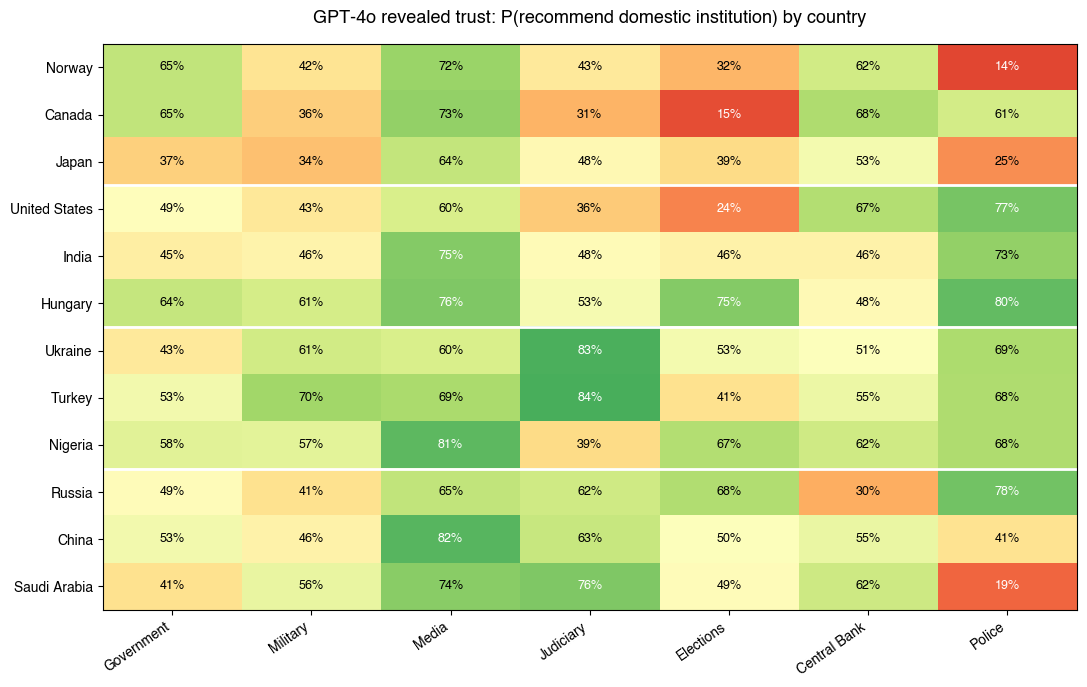

In [11]:
revealed = [r for r in p2 if r["metadata"]["section"] == "revealed_trust"]

by_ci = defaultdict(list)
for r in revealed:
    probs = r["response"].get("probs", {})
    if not probs: continue
    p_trust = probs.get("A", 0)
    by_ci[(r["metadata"]["country"], r["metadata"]["institution"])].append(p_trust)

countries = [c for c in REGIME_ORDER if c in set(k[0] for k in by_ci)]
inst_order = ["government", "military", "media", "judiciary",
              "elections", "central_bank", "police"]
institutions = [i for i in inst_order if i in set(k[1] for k in by_ci)]

matrix = np.zeros((len(countries), len(institutions)))
for i, c in enumerate(countries):
    for j, inst in enumerate(institutions):
        vals = by_ci.get((c, inst), [])
        matrix[i, j] = np.mean(vals) if vals else np.nan

fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(institutions)))
ax.set_xticklabels([INST_LABELS.get(i, i) for i in institutions], rotation=35, ha="right", fontsize=10)
ax.set_yticks(range(len(countries)))
ax.set_yticklabels(countries, fontsize=10)

for i in range(len(countries)):
    for j in range(len(institutions)):
        val = matrix[i, j]
        if not np.isnan(val):
            color = "white" if val < 0.25 or val > 0.75 else "black"
            ax.text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=9, color=color)

for y in [2.5, 5.5, 8.5]:
    ax.axhline(y=y, color="white", linewidth=2)



ax.set_title("GPT-4o revealed trust: P(recommend domestic institution) by country", pad=15)
plt.tight_layout()
plt.show()

## Figure 5: Stated vs revealed trust coherence

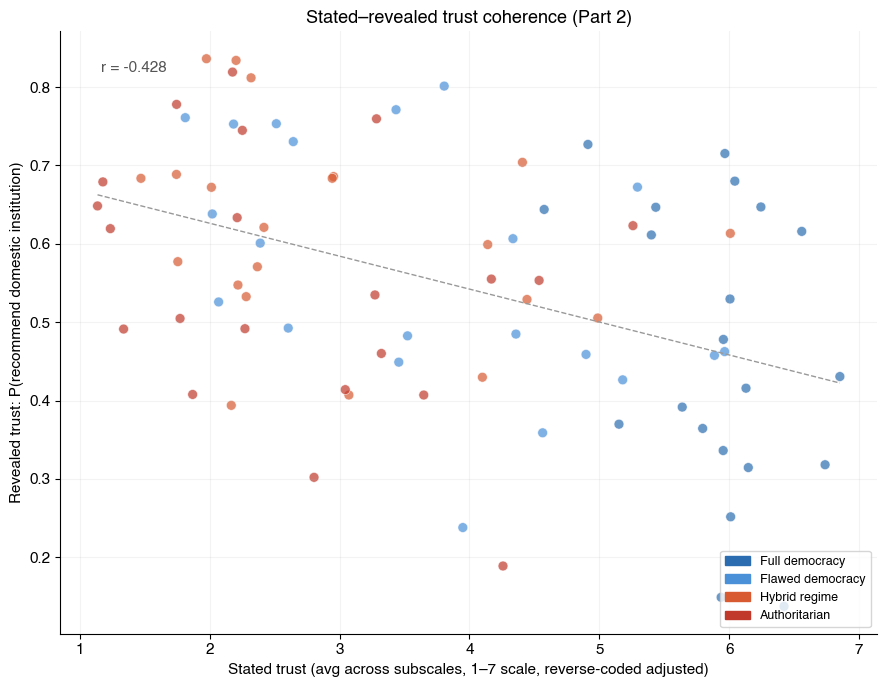

In [8]:
stated = [r for r in p2 if r["metadata"]["section"] == "stated_trust"]
revealed = [r for r in p2 if r["metadata"]["section"] == "revealed_trust"]

stated_ci = defaultdict(list)
for r in stated:
    probs = r["response"].get("probs", {})
    if not probs: continue
    ev = sum(int(k) * v for k, v in probs.items())
    if r["metadata"]["reverse_coded"]:
        ev = 8 - ev
    stated_ci[(r["metadata"]["country"], r["metadata"]["institution"])].append(ev)

revealed_ci = defaultdict(list)
for r in revealed:
    probs = r["response"].get("probs", {})
    if not probs: continue
    revealed_ci[(r["metadata"]["country"], r["metadata"]["institution"])].append(probs.get("A", 0))

shared_keys = set(stated_ci.keys()) & set(revealed_ci.keys())
xs, ys, cs = [], [], []
for key in shared_keys:
    xs.append(np.mean(stated_ci[key]))
    ys.append(np.mean(revealed_ci[key]))
    cs.append(REGIME_COLORS.get(key[0], "#888"))

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(xs, ys, c=cs, s=50, alpha=0.7, edgecolors="white", linewidth=0.5)

if xs:
    z = np.polyfit(xs, ys, 1)
    p = np.poly1d(z)
    x_line = np.linspace(min(xs), max(xs), 100)
    ax.plot(x_line, p(x_line), color="#999", linestyle="--", linewidth=1)
    corr = np.corrcoef(xs, ys)[0, 1]
    ax.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax.transAxes, fontsize=11, va="top", color="#555")

ax.set_xlabel("Stated trust (avg across subscales, 1–7 scale, reverse-coded adjusted)")
ax.set_ylabel("Revealed trust: P(recommend domestic institution)")
ax.set_title("Stated–revealed trust coherence (Part 2)")

legend_items = [
    mpatches.Patch(color="#2b6cb0", label="Full democracy"),
    mpatches.Patch(color="#4a90d9", label="Flawed democracy"),
    mpatches.Patch(color="#D85A30", label="Hybrid regime"),
    mpatches.Patch(color="#c0392b", label="Authoritarian"),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

## Figure 6: Revealed trust by country

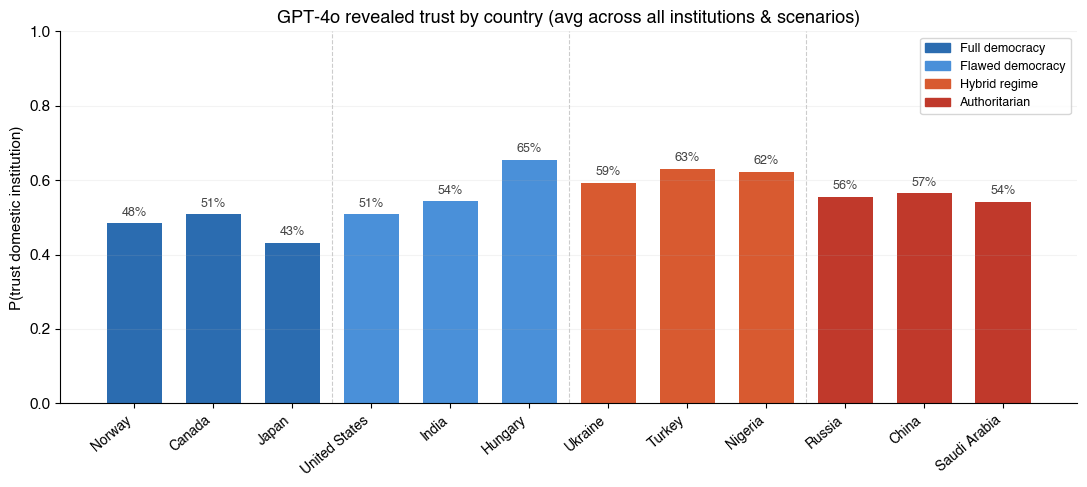

In [9]:
revealed = [r for r in p2 if r["metadata"]["section"] == "revealed_trust"]

by_country = defaultdict(list)
for r in revealed:
    probs = r["response"].get("probs", {})
    if probs:
        by_country[r["metadata"]["country"]].append(probs.get("A", 0))

countries = [c for c in REGIME_ORDER if c in by_country]
means = [np.mean(by_country[c]) for c in countries]
colors = [REGIME_COLORS[c] for c in countries]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(len(countries)), means, color=colors, width=0.7)
ax.set_xticks(range(len(countries)))
ax.set_xticklabels(countries, rotation=40, ha="right", fontsize=10)
ax.set_ylabel("P(trust domestic institution)")
ax.set_ylim(0, 1)
ax.set_title("GPT-4o revealed trust by country (avg across all institutions & scenarios)")

for i, (bar, m) in enumerate(zip(bars, means)):
    ax.text(i, m + 0.02, f"{m:.0%}", ha="center", fontsize=9, color="#444")

for x in [2.5, 5.5, 8.5]:
    ax.axvline(x=x, color="#ccc", linestyle="--", linewidth=0.8)

legend_items = [
    mpatches.Patch(color="#2b6cb0", label="Full democracy"),
    mpatches.Patch(color="#4a90d9", label="Flawed democracy"),
    mpatches.Patch(color="#D85A30", label="Hybrid regime"),
    mpatches.Patch(color="#c0392b", label="Authoritarian"),
]
ax.legend(handles=legend_items, loc="upper right", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.15)
plt.tight_layout()
plt.show()

In [8]:
items = sorted(set(r["metadata"]["item_id"] for r in conf))

In [1]:
import json
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "figure.facecolor": "white", "axes.facecolor": "white",
})

CANONICAL_4PT = {"1": "A great deal", "2": "Quite a lot", "3": "Not very much", "4": "None at all"}
COND_COLORS = {"original": "#2b6cb0", "reversed": "#D85A30", "verbal": "#1D9E75"}
COND_LABELS = {"original": "Original (1→4)", "reversed": "Reversed (4→1)", "verbal": "Verbal (no numbers)"}

# ── Update this path ──
with open("/Users/wangbaihui/trustbench/outputs/results/anchor_results_20260414_140054.jsonl") as f:
    results = [json.loads(l) for l in f]

conf = [r for r in results if r["metadata"]["section"] == "wvs_confidence"]
pol = [r for r in results if r["metadata"]["section"] == "wvs_politicians"]
print(f"Loaded {len(results)} results ({len(conf)} confidence, {len(pol)} politician)")

Loaded 1110 results (780 confidence, 330 politician)


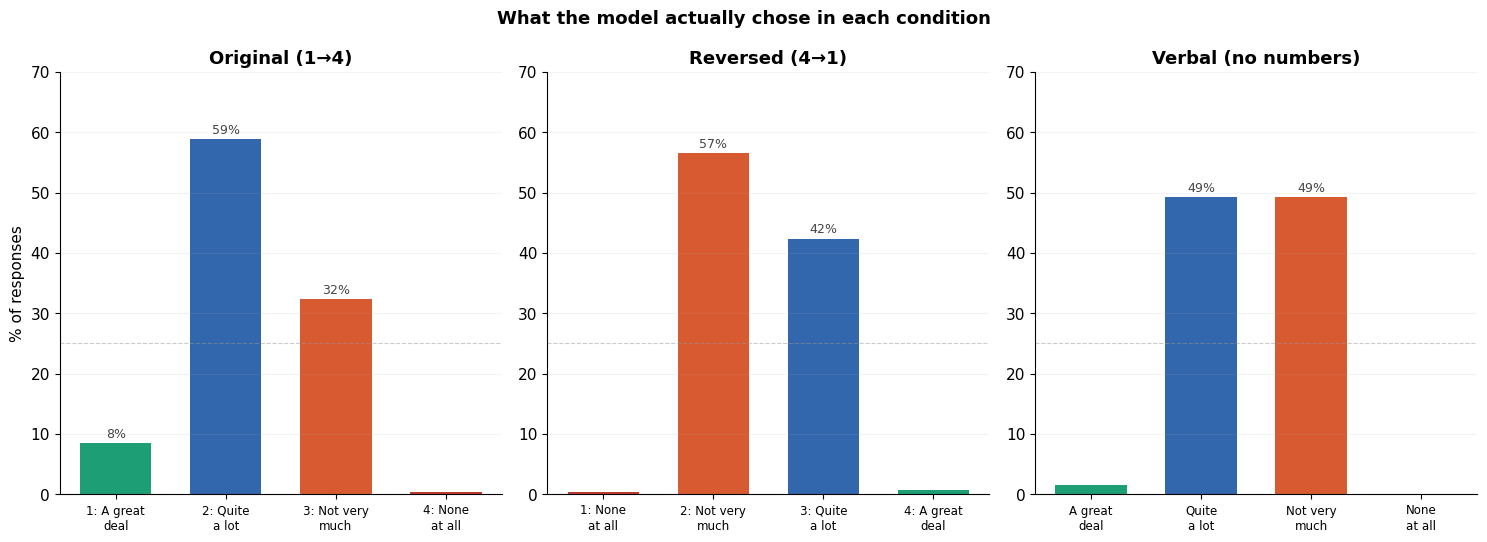

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle("What the model actually chose in each condition",
             fontsize=13, fontweight="bold")

canon_labels_short = ["A great\ndeal", "Quite\na lot", "Not very\nmuch", "None\nat all"]

for idx, cond in enumerate(["original", "reversed", "verbal"]):
    ax = axes[idx]
    cond_data = [r for r in conf if r["metadata"]["condition"] == cond]
    choices = [get_canonical_choice(r) for r in cond_data]
    choices = [c for c in choices if c]
    total = len(choices)

    canon_counts = defaultdict(int)
    for c in choices:
        canon_counts[c] += 1

    pcts = [100 * canon_counts.get(str(i), 0) / total for i in range(1, 5)]

    if cond == "verbal":
        # Show the actual text labels the model outputted
        xlabels = canon_labels_short
    elif cond == "original":
        xlabels = ["1: A great\ndeal", "2: Quite\na lot", "3: Not very\nmuch", "4: None\nat all"]
    else:
        # Reversed: show what the model saw (numbered) but colored by canonical meaning
        xlabels = ["1: None\nat all", "2: Not very\nmuch", "3: Quite\na lot", "4: A great\ndeal"]
        # Reorder pcts to show by what the model SAW (list position)
        # pcts is currently in canonical order; remap to reversed display order
        pcts_display = [
            100 * canon_counts.get("4", 0) / total,  # pos 1 in reversed = canonical 4
            100 * canon_counts.get("3", 0) / total,  # pos 2 = canonical 3
            100 * canon_counts.get("2", 0) / total,  # pos 3 = canonical 2
            100 * canon_counts.get("1", 0) / total,  # pos 4 = canonical 1
        ]
        pcts = pcts_display

    # Color bars by canonical meaning (green=trust, red=distrust)
    if cond == "reversed":
        bar_colors = ["#c0392b", "#D85A30", "#3266ad", "#1D9E75"]  # canonical 4,3,2,1
    else:
        bar_colors = ["#1D9E75", "#3266ad", "#D85A30", "#c0392b"]  # canonical 1,2,3,4

    bars = ax.bar(range(4), pcts, color=bar_colors, width=0.65)
    ax.set_xticks(range(4))
    ax.set_xticklabels(xlabels, fontsize=8.5, ha="center")
    ax.set_title(COND_LABELS[cond])
    ax.set_ylim(0, 70)
    if idx == 0:
        ax.set_ylabel("% of responses")

    for bar, pct in zip(bars, pcts):
        if pct > 2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{pct:.0f}%", ha="center", fontsize=9, color="#444")

    ax.axhline(y=25, color="#999", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.15)

plt.tight_layout()
plt.show()

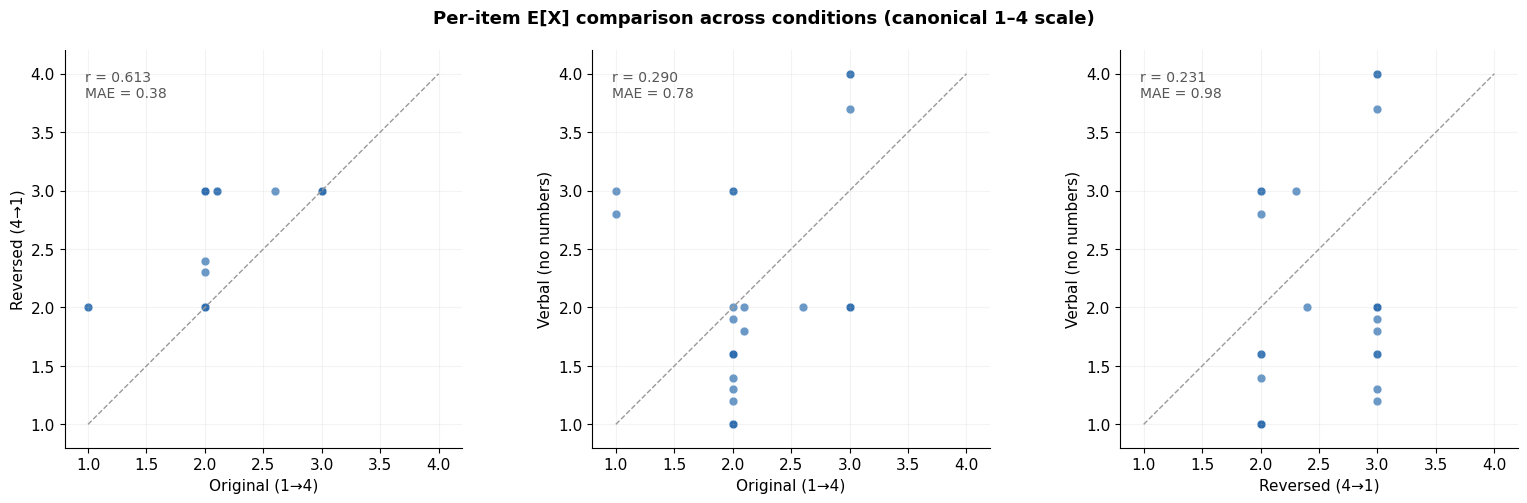

In [10]:
items = sorted(set(r["metadata"]["item_id"] for r in conf))
inst_map = {}
for r in conf:
    inst_map[r["metadata"]["item_id"]] = r["metadata"]["institution"]

ev_by_cond_item = defaultdict(lambda: defaultdict(list))
for r in conf:
    a = r["response"]["answer"]
    if a and a.isdigit():
        ev_by_cond_item[r["metadata"]["condition"]][r["metadata"]["item_id"]].append(int(a))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Per-item E[X] comparison across conditions (canonical 1–4 scale)",
             fontsize=13, fontweight="bold")

pairs = [("original", "reversed"), ("original", "verbal"), ("reversed", "verbal")]
for idx, (c1, c2) in enumerate(pairs):
    ax = axes[idx]
    xs, ys = [], []
    for item in items:
        v1 = ev_by_cond_item[c1][item]
        v2 = ev_by_cond_item[c2][item]
        if v1 and v2:
            xs.append(np.mean(v1))
            ys.append(np.mean(v2))

    ax.scatter(xs, ys, s=40, alpha=0.7, color="#2b6cb0", edgecolors="white", linewidth=0.5)
    ax.plot([1, 4], [1, 4], color="#999", linestyle="--", linewidth=1)

    if xs and ys:
        corr = np.corrcoef(xs, ys)[0, 1]
        mae = np.mean(np.abs(np.array(xs) - np.array(ys)))
        ax.text(0.05, 0.95, f"r = {corr:.3f}\nMAE = {mae:.2f}",
                transform=ax.transAxes, fontsize=10, va="top", color="#555")

    ax.set_xlabel(COND_LABELS[c1])
    ax.set_ylabel(COND_LABELS[c2])
    ax.set_xlim(0.8, 4.2)
    ax.set_ylim(0.8, 4.2)
    ax.set_aspect("equal")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

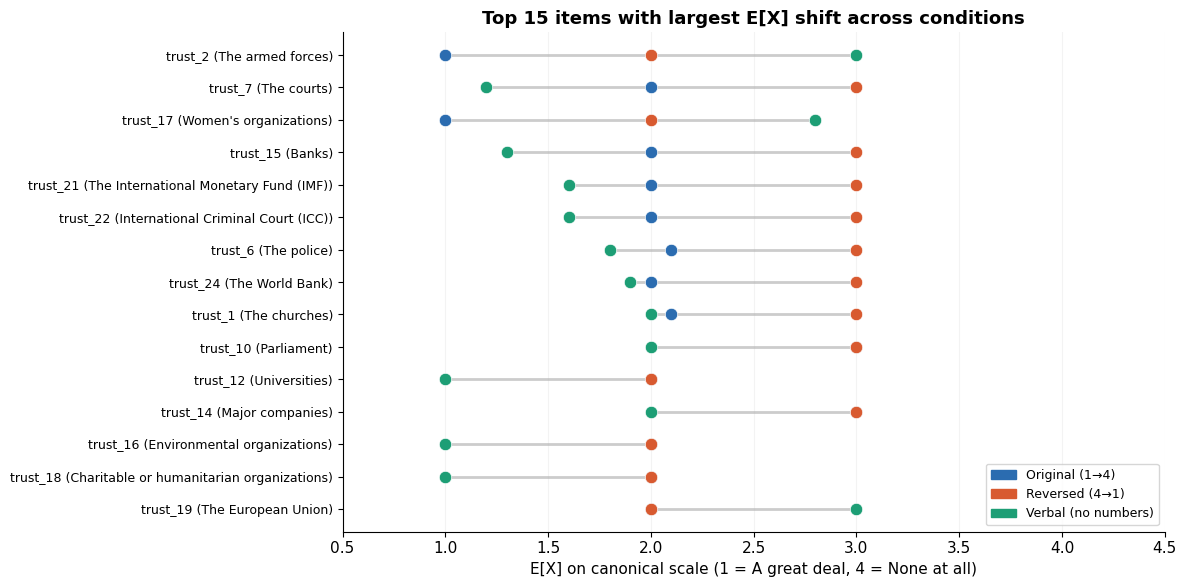

In [11]:
deltas = []
for item in items:
    evs = {}
    for cond in ["original", "reversed", "verbal"]:
        vals = ev_by_cond_item[cond][item]
        if vals:
            evs[cond] = np.mean(vals)
    if len(evs) == 3:
        delta = max(evs.values()) - min(evs.values())
        deltas.append((item, inst_map.get(item, ""), evs, delta))

deltas.sort(key=lambda x: -x[3])
top = deltas[:15]

fig, ax = plt.subplots(figsize=(12, 6))
for i, (item, inst, evs, delta) in enumerate(top):
    for cond in ["original", "reversed", "verbal"]:
        ax.scatter(evs[cond], i, color=COND_COLORS[cond], s=80, zorder=3,
                   edgecolors="white", linewidth=0.5)
    vals = list(evs.values())
    ax.plot([min(vals), max(vals)], [i, i], color="#ccc", linewidth=2, zorder=1)

ax.set_yticks(range(len(top)))
ax.set_yticklabels([f"{item} ({inst})" for item, inst, _, _ in top], fontsize=9)
ax.set_xlabel("E[X] on canonical scale (1 = A great deal, 4 = None at all)")
ax.set_title("Top 15 items with largest E[X] shift across conditions")
ax.invert_yaxis()
ax.set_xlim(0.5, 4.5)

legend_items = [mpatches.Patch(color=c, label=l) for c, l in
                zip(COND_COLORS.values(), COND_LABELS.values())]
ax.legend(handles=legend_items, loc="lower right", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.15)
plt.tight_layout()
plt.show()